In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
cd /content/gdrive/My Drive/Colab Notebooks/

/content/gdrive/My Drive/Colab Notebooks


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

# **1. Loading Data**

In [5]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Dataset Info")
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


# **2. Preprocessing & Feature Engineering**

In [6]:
#Datetime Index
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

df = df.sort_values(by=['Region', 'Model', 'Date'])

#Time-Based Features
df['Quarter'] = df['Date'].dt.quarter
df['Is_Year_End'] = df['Month'].apply(lambda x: 1 if x in [11, 12] else 0)

#Domain-Specific Features
df['Efficiency_km_per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh']
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

#Lag & Rolling Features (Time Series Memory)

grouped = df.groupby(['Region', 'Model'])
df['Deliveries_Last_Month'] = grouped['Estimated_Deliveries'].shift(1)
df['Deliveries_3M_Rolling_Avg'] = grouped['Estimated_Deliveries'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

df['Deliveries_Last_Month'] = df['Deliveries_Last_Month'].fillna(0)
df['Deliveries_3M_Rolling_Avg'] = df['Deliveries_3M_Rolling_Avg'].fillna(0)

# **3. Exploratory Data Analysis (EDA)**

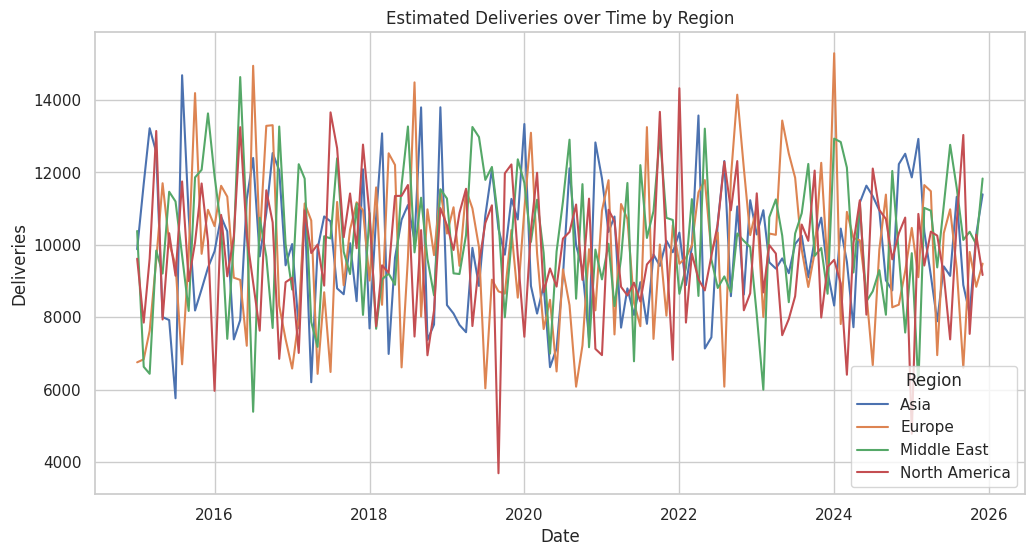

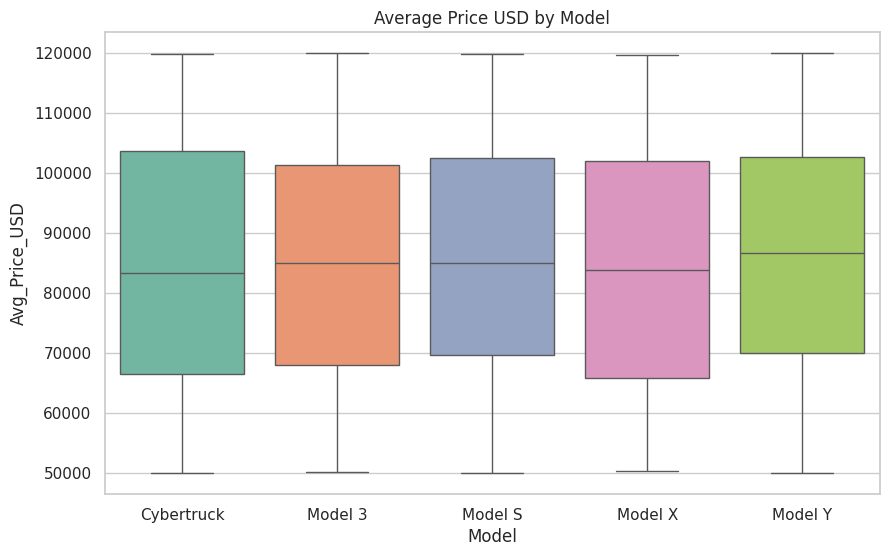

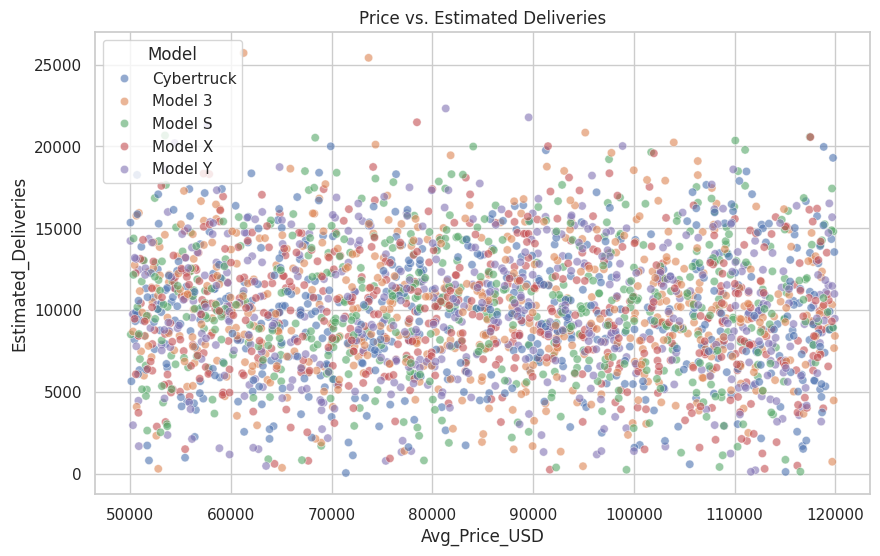

In [7]:
sns.set_theme(style="whitegrid")

# Plot 1: Deliveries over Time by Region
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated_Deliveries', hue='Region', errorbar=None)
plt.title('Estimated Deliveries over Time by Region')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.show()

# Plot 2: Average Price by Model
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='Set2')
plt.title('Average Price USD by Model')
plt.show()

# Plot 3: Price vs. Deliveries
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Price_USD', y='Estimated_Deliveries', hue='Model', alpha=0.6)
plt.title('Price vs. Estimated Deliveries')
plt.show()

# **4. Regression Modeling**

In [8]:
# Features (X) and Target (y)
X = df.drop(columns=['Estimated_Deliveries', 'Date', 'CO2_Saved_tons', 'Production_Units'])
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column types
categorical_cols = ['Region', 'Model', 'Source_Type']
numerical_cols = [
    'Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'Charging_Stations', 'Quarter', 'Is_Year_End', 'Efficiency_km_per_kWh',
    'Price_per_km', 'Deliveries_Last_Month', 'Deliveries_3M_Rolling_Avg'
]

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Build pipeline with Random Forest
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# **5. Hyperparameter tuning using RandomizedSearchCV**

In [9]:
param_distributions = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

# **6. Predictions and Evaluation**

In [10]:
y_pred = best_model.predict(X_test)

print("Regression Results")
print(f"Best Parameters: {search.best_params_}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

Regression Results
Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 10}
R² Score: -0.0287
RMSE: 3974.18
MAE: 3172.90


# **7. Time Series Forecasting (SARIMAX)**

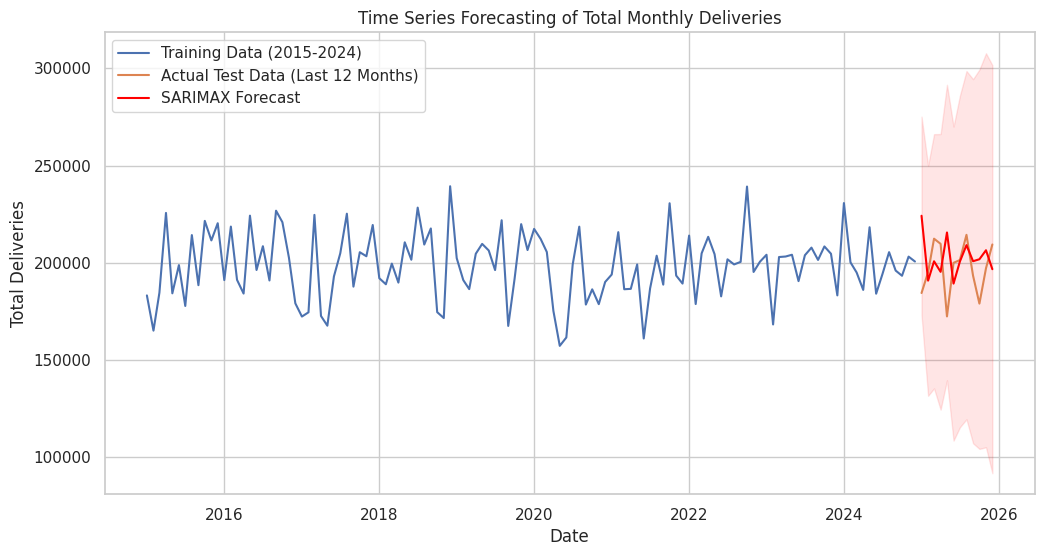

In [11]:
# Aggregate total deliveries globally by month
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_data.set_index('Date', inplace=True)
ts_data = ts_data.asfreq('MS')

# Train/Test Split for Time Series
train_ts = ts_data.iloc[:-12]
test_ts = ts_data.iloc[-12:]

# Fit SARIMA Model
model_ts = SARIMAX(train_ts['Estimated_Deliveries'],
                   order=(1, 1, 1),
                   seasonal_order=(1, 1, 0, 12))
results_ts = model_ts.fit(disp=False)

# Forecast the next 12 months
forecast = results_ts.get_forecast(steps=12)
pred_ts = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot Forecasting Results
plt.figure(figsize=(12, 6))
plt.plot(train_ts.index, train_ts['Estimated_Deliveries'], label='Training Data (2015-2024)')
plt.plot(test_ts.index, test_ts['Estimated_Deliveries'], label='Actual Test Data (Last 12 Months)')
plt.plot(pred_ts.index, pred_ts, color='red', label='SARIMAX Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1)

plt.title('Time Series Forecasting of Total Monthly Deliveries')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.show()